#Seasonal Agriculture performance Analysis

Major Data Analytics project

**Domain**: Agriculture

**Tools**: Python,pandas,numpy,matplotlib,seaborn

**PROJECT GOAL-**

To identify and analyze seasonal patterns and differences in agricultural performance using data analytics techniques, in order to support evidence based agricultural planning.

**Problem Statement**

Agricultural activities are influenced by seasonal variations in environmental conditions, farming practices, resource availability, and market conditions. As a result, agricultural performance may differ from one season to another.

Raw agricultural data does not clearly explain how agricultural performance changes across seasons or what patterns can be observed in different seasonal conditions. The problem is to analyze the given agricultural dataset and investigate seasonal differences in agricultural performance by identifying meaningful patterns, trends, relationships, and variations within the available data.

**Objective**


The primary objective of this project is to analyze agricultural data from different seasons and identify meaningful patterns, trends, relationships, and differences in agricultural performance

-Explore and understand the dataset

-Clean and prepare the data for analysis

-Examine how agricultural performance varies across seasons

-Identify important seasonal patterns and trends

-Investigate relationships between seasonal conditions and agricultural outcomes

-Compare relevant groups within different seasons

-Identify significant differences or unusual patterns

-Apply appropriate statistical and visualization techniques

-Interpret findings based on evidence from the dataset

-Develop meaningful conclusions and data-driven recommendations











##Import Libraries

In this section, we import the Python libraries needed for data analysis and visualization.

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


##Load Dataset

In [28]:
df = pd.read_csv('/content/seasonal_agriculture_performance_dataset.csv')
df.head()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,...,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,...,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,...,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,...,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,...,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


##Basic Data Exploration

In [29]:
df.shape

(4000, 28)

In [30]:
df.columns

Index(['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Farm_Area_Hectares',
       'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct',
       'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha',
       'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Irrigation_Method',
       'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score',
       'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne',
       'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3',
       'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct'],
      dtype='object')

In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   object 
 1   State                          4000 non-null   object 
 2   District                       4000 non-null   object 
 3   Crop                           4000 non-null   object 
 4   Season                         4000 non-null   object 
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   f

In [32]:
df.describe()

,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
count,4000.000000,3952.000000,4000.00000,4000.000000,4000.000000,4000.000000,3960.000000,4000.000000,4000.000000,4000.000000,...,4000.000000,3968.000000,4000.000000,4000.000000,4.000000e+03,4.000000e+03,4.000000e+03,4000.000000,4000.000000,4000.000000
mean,7.888265,601.152657,26.81890,63.210500,7.323050,6.701010,26.508232,120.250825,57.781850,104.760050,...,0.826138,5.270595,43.246210,44714.166250,5.263036e+05,6.378600e+05,1.115565e+05,6045.570250,5.385214,46.365875
std,4.223764,288.925025,3.81818,11.960834,1.121186,0.641461,6.712484,31.216452,17.015074,27.742681,...,0.101747,13.361398,126.880521,30266.161922,2.944191e+05,6.369747e+05,5.450819e+05,5572.944306,8.838101,12.424417
min,0.500000,80.000000,16.20000,25.000000,3.500000,5.200000,8.000000,40.000000,15.000000,30.000000,...,0.650000,0.300000,0.150000,2594.000000,2.682600e+04,6.107000e+03,-1.019223e+06,128.000000,0.135000,5.000000
25%,4.260000,370.200000,23.90000,54.775000,6.600000,6.260000,21.700000,98.500000,46.200000,86.200000,...,0.740000,1.050000,5.020000,21429.250000,2.745775e+05,2.075172e+05,-1.487318e+05,2268.750000,1.661000,37.300000
50%,7.895000,582.000000,26.90000,63.000000,7.300000,6.690000,26.400000,120.100000,57.500000,105.100000,...,0.830000,1.740000,11.770000,25913.000000,5.190825e+05,4.568305e+05,3.673000e+03,4435.000000,2.937500,46.400000
75%,11.650000,834.950000,29.60000,71.900000,8.100000,7.140000,31.300000,141.225000,69.400000,123.600000,...,0.910000,2.840000,24.355000,68279.000000,7.619965e+05,8.368748e+05,2.161878e+05,7829.750000,5.150250,54.900000
max,15.000000,1395.200000,39.70000,95.000000,11.000000,8.400000,47.000000,220.000000,120.000000,200.000000,...,1.000000,101.440000,1424.400000,131240.000000,1.349990e+06,5.080900e+06,4.345421e+06,40902.000000,79.800000,88.900000


##Check Missing Value and Duplicates

In [33]:
df.isnull().sum()

,0
Farm_ID,0
State,0
District,0
Crop,0
Season,0
Farm_Area_Hectares,0
Rainfall_mm,48
Avg_Temperature_C,0
Humidity_pct,0
Sunlight_Hours_Day,0


##Data Cleaning

We remove duplicate rows and fill missing numeric values with the median so the analyse stay accurate.

In [34]:
df = df.drop_duplicates()

numeric_cols = df.select_dtypes(include=[np.number]).columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

print("After cleaning:", df.shape)

After cleaning: (4000, 28)


In [35]:
df.isnull().sum()

,0
Farm_ID,0
State,0
District,0
Crop,0
Season,0
Farm_Area_Hectares,0
Rainfall_mm,0
Avg_Temperature_C,0
Humidity_pct,0
Sunlight_Hours_Day,0


##Season-wise Performance Summary
We compare the average Yield, Production, Profit, Rainfall, and Water Efficiency across Kharif, Rabi, and Zaid seasons.

In [36]:
season_summary = df.groupby('Season')[['Yield_Tonnes_Ha', 'Production_Tonnes',
                                         'Profit_INR', 'Rainfall_mm',
                                         'Water_Efficiency_t_per_1000m3']].mean()
print(season_summary)

        Yield_Tonnes_Ha  Production_Tonnes     Profit_INR  Rainfall_mm  \
Season                                                                   
Kharif         5.628612          46.311192  178914.647555   849.199663   
Rabi           5.039435          41.486712   87689.470191   437.615366   
Zaid           4.641313          38.886111  -24804.824916   304.654714   

        Water_Efficiency_t_per_1000m3  
Season                                 
Kharif                       5.891834  
Rabi                         5.186122  
Zaid                         4.413239  


## Yield Distribution Across Seasons

Boxplot show how Yield is distributed within each season, including spread and outliers.


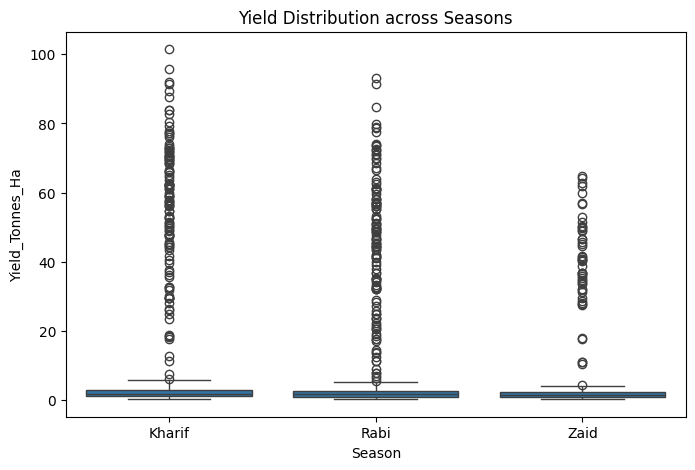

In [37]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Season', y='Yield_Tonnes_Ha', data=df)
plt.title('Yield Distribution across Seasons')
plt.show()

##Average Profit Comparison

Bar chart compares average profit across seasons

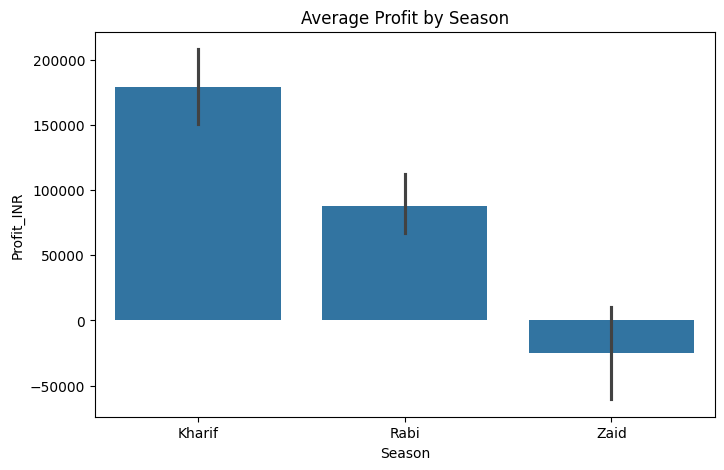

In [38]:
plt.figure(figsize=(8,5))
sns.barplot(x='Season', y='Profit_INR', data=df, estimator=np.mean)
plt.title('Average Profit by Season')
plt.show()

##Correlation Heatmap

 It shows the relationship between environmental factors and Yield.

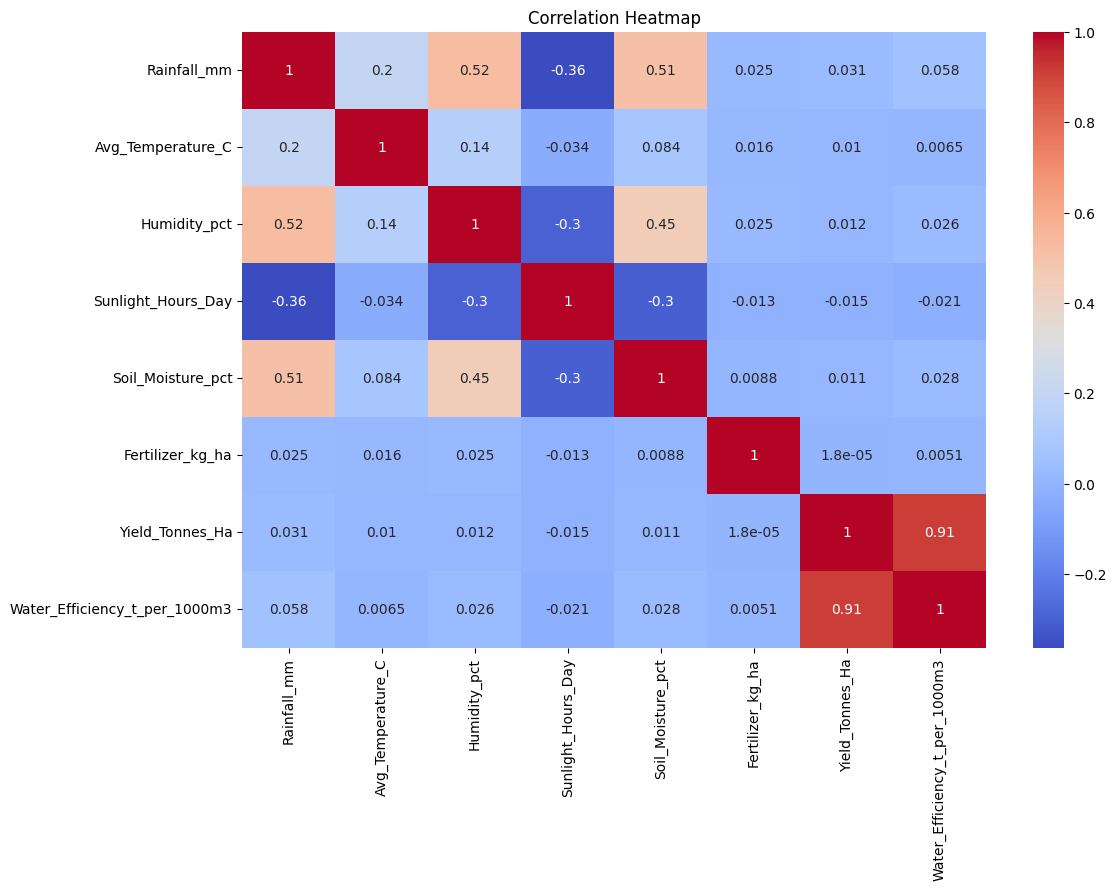

In [39]:
plt.figure(figsize=(12,8))
corr = df[['Rainfall_mm','Avg_Temperature_C','Humidity_pct','Sunlight_Hours_Day',
           'Soil_Moisture_pct','Fertilizer_kg_ha','Yield_Tonnes_Ha',
           'Water_Efficiency_t_per_1000m3']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

##  Crop Distribution Across Seasons
We look that which crops are grown more frequently in which season.

Crop    Chilli  Cotton  Groundnut  Maize  Pulses  Rice  Sugarcane  Wheat
Season                                                                  
Kharif     185     215        193    234     221   314        125    292
Rabi       163     201        177    233     213   274        129    237
Zaid        64      92         54     84      62   102         51     85


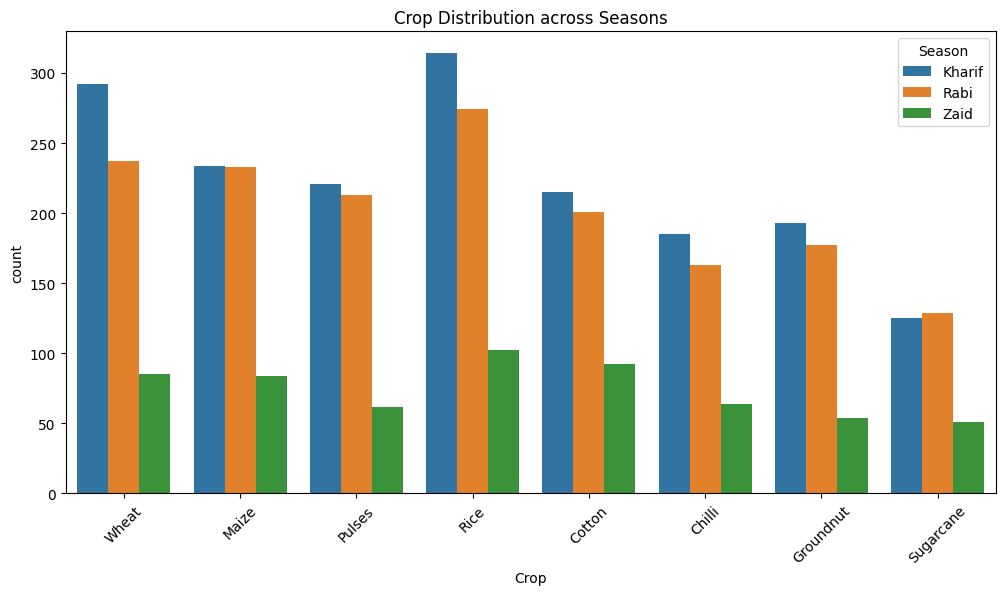

In [40]:
crop_season = pd.crosstab(df['Season'], df['Crop'])
print(crop_season)

plt.figure(figsize=(12,6))
sns.countplot(x='Crop', hue='Season', data=df)
plt.title('Crop Distribution across Seasons')
plt.xticks(rotation=45)
plt.show()

##Environmental Conditions by Season
We compare the average rainfall, temperature, humidity, sunlight, and soil moisture across seasons.

        Rainfall_mm  Avg_Temperature_C  Humidity_pct  Sunlight_Hours_Day  \
Season                                                                     
Kharif       849.20              28.45         71.81                6.79   
Rabi         437.62              23.49         57.89                7.59   
Zaid         304.65              31.04         52.01                8.18   

        Soil_Moisture_pct  
Season                     
Kharif              31.15  
Rabi                24.07  
Zaid                19.28  


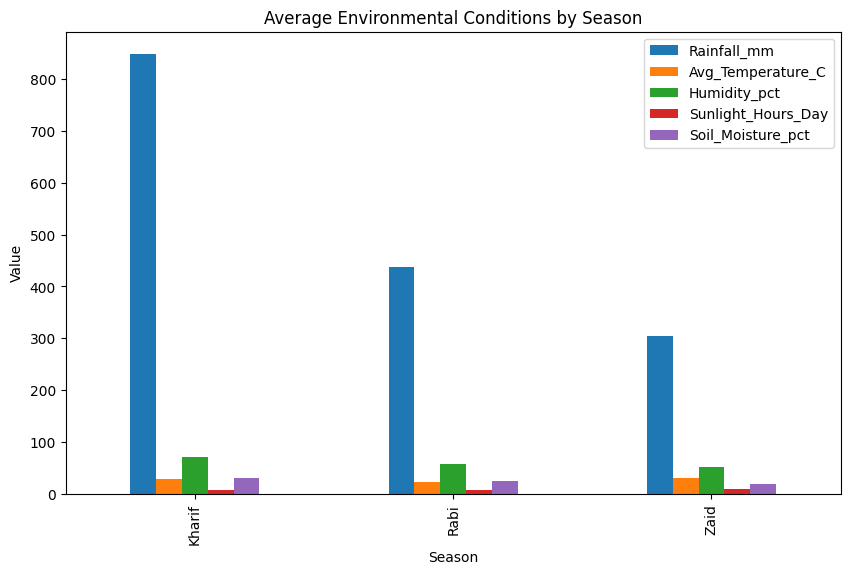

In [41]:
env_cols = ['Rainfall_mm','Avg_Temperature_C','Humidity_pct','Sunlight_Hours_Day','Soil_Moisture_pct']
env_summary = df.groupby('Season')[env_cols].mean().round(2)
print(env_summary)

env_summary.plot(kind='bar', figsize=(10,6))
plt.title('Average Environmental Conditions by Season')
plt.ylabel('Value')
plt.show()

##Resource Usage Comparison
We check how fertilizer, pesticide, and water usage differ across seasons.

        Fertilizer_kg_ha  Pesticide_Litre_ha  Water_Used_m3
Season                                                     
Kharif            187.08                5.08        6102.20
Rabi              185.41                5.02        5846.99
Zaid              184.64                5.17        6419.89


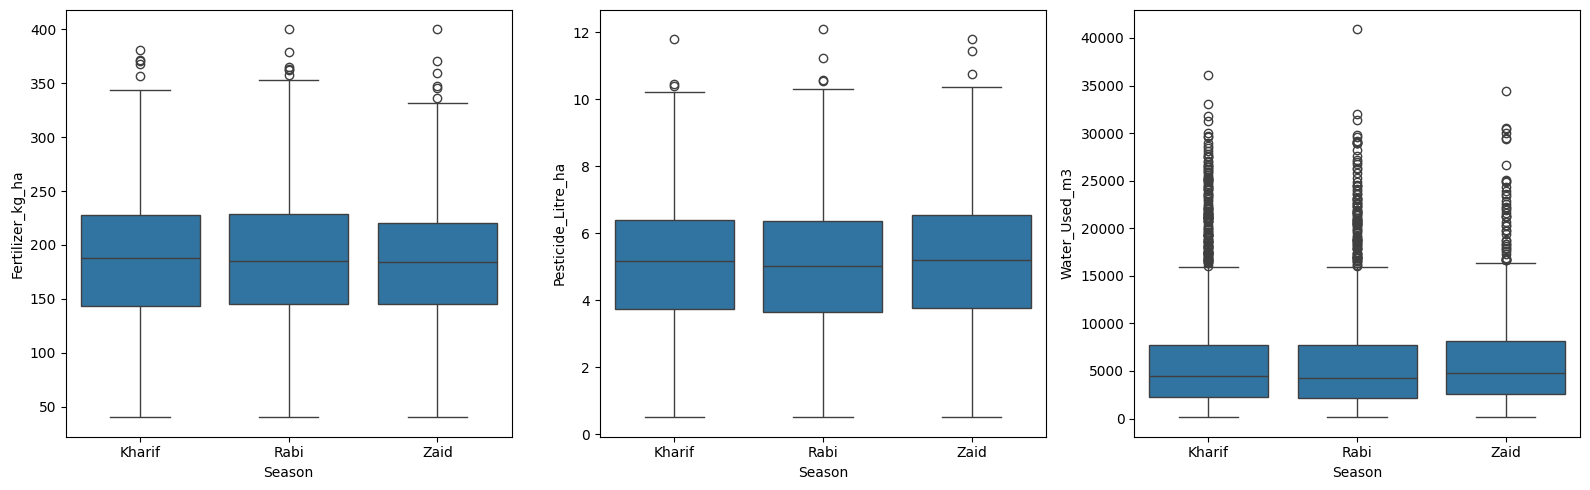

In [42]:
resource_cols = ['Fertilizer_kg_ha','Pesticide_Litre_ha','Water_Used_m3']
resource_summary = df.groupby('Season')[resource_cols].mean().round(2)
print(resource_summary)

fig, axes = plt.subplots(1, 3, figsize=(16,5))
for i, col in enumerate(resource_cols):
    sns.boxplot(x='Season', y=col, data=df, ax=axes[i])
plt.tight_layout()
plt.show()

##Economic Performance by Season
It compare total cost, revenue, profit, and profit margin (%) across seasons.

        Total_Cost_INR  Revenue_INR  Profit_INR  Profit_Margin_pct
Season                                                            
Kharif       531804.41    710719.06   178914.65             -38.64
Rabi         513836.58    601526.05    87689.47             -44.27
Zaid         543976.73    519171.90   -24804.82             -69.35


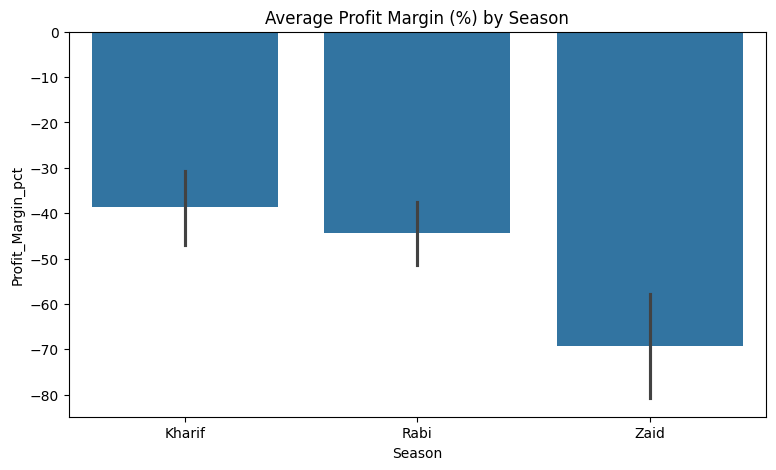

In [43]:
df['Profit_Margin_pct'] = (df['Profit_INR'] / df['Revenue_INR']) * 100

econ_summary = df.groupby('Season')[['Total_Cost_INR','Revenue_INR','Profit_INR','Profit_Margin_pct']].mean().round(2)
print(econ_summary)

plt.figure(figsize=(9,5))
sns.barplot(x='Season', y='Profit_Margin_pct', data=df)
plt.title('Average Profit Margin (%) by Season')
plt.show()

##  Rainfall vs Yield Relationship
A scatter plot shows the relationship between rainfall and yield, broken down by season.

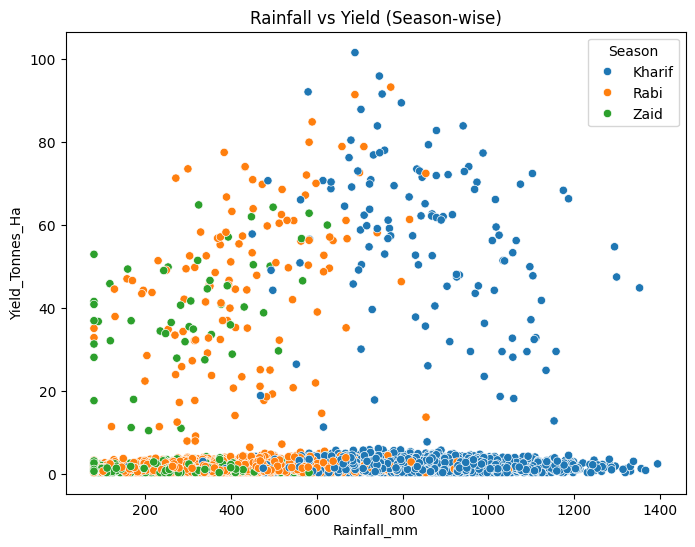

In [44]:
plt.figure(figsize=(8,6))
sns.scatterplot(x='Rainfall_mm', y='Yield_Tonnes_Ha', hue='Season', data=df)
plt.title('Rainfall vs Yield (Season-wise)')
plt.show()

## State-wise Seasonal Pattern
We check whether the seasonal yield pattern is consistent across states or varies by region.

Season          Kharif  Rabi  Zaid
State                             
Andhra Pradesh    5.68  3.47  4.45
Gujarat           6.34  5.44  4.07
Karnataka         6.46  4.57  6.62
Madhya Pradesh    5.99  3.76  5.48
Maharashtra       5.43  5.50  2.28
Punjab            4.10  8.61  5.91
Tamil Nadu        5.52  4.50  4.10
Telangana         5.55  4.78  4.25


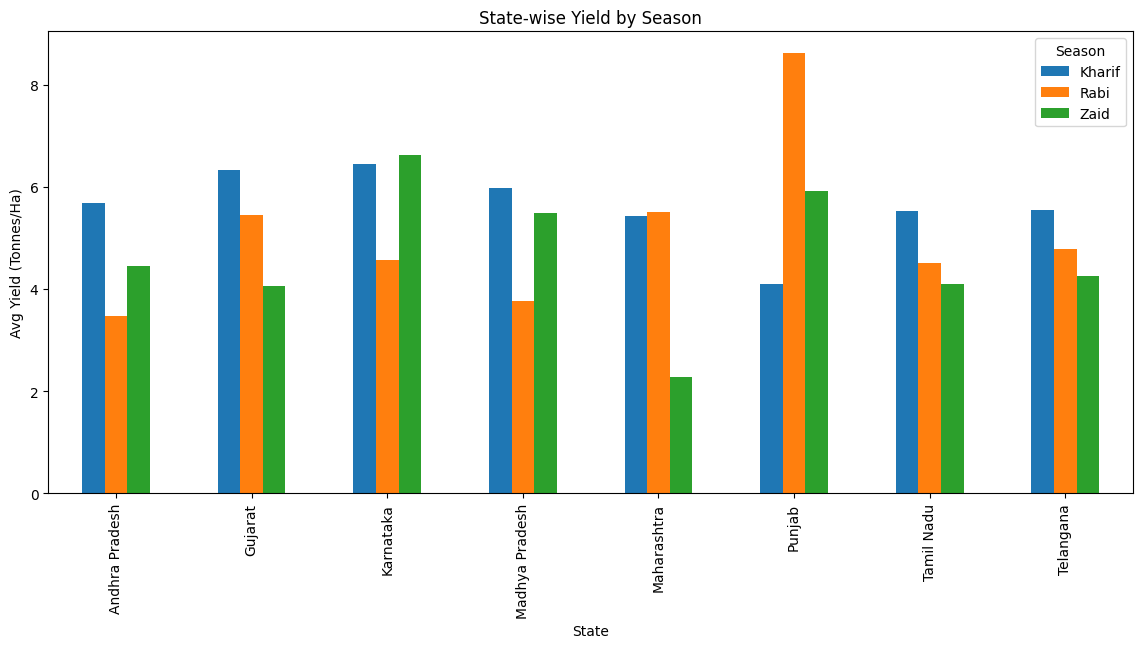

In [45]:
state_season = df.groupby(['State','Season'])['Yield_Tonnes_Ha'].mean().unstack()
print(state_season.round(2))

state_season.plot(kind='bar', figsize=(14,6))
plt.title('State-wise Yield by Season')
plt.ylabel('Avg Yield (Tonnes/Ha)')
plt.show()

## Irrigation Method Effect on Water Efficiency

We compare water efficiency across different irrigation methods within each season to see which combination performs best.

Irrigation_Method  Drip  Flood  Rainfed  Sprinkler
Season                                            
Kharif             6.80   3.64     8.85       4.62
Rabi               6.05   3.48     6.87       4.64
Zaid               5.30   2.73     5.48       4.86


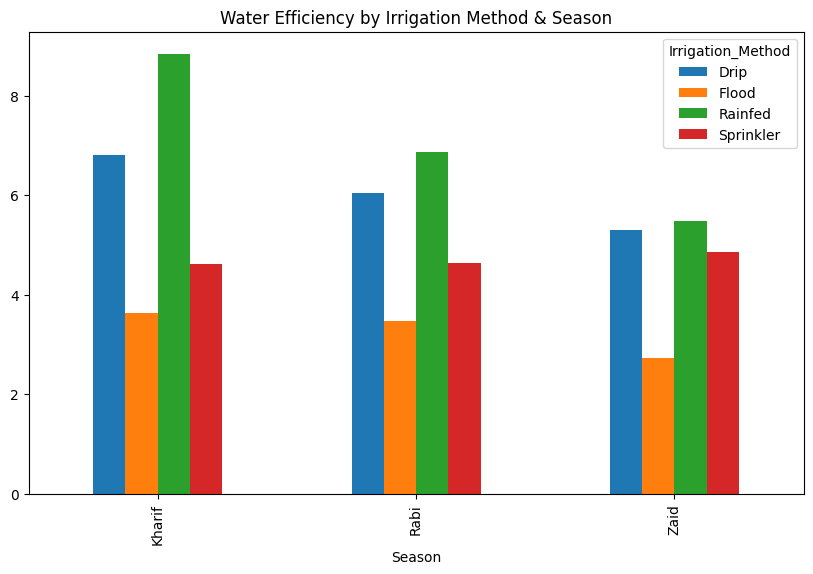

In [46]:
irrigation_summary = df.groupby(['Season','Irrigation_Method'])['Water_Efficiency_t_per_1000m3'].mean().unstack()
print(irrigation_summary.round(2))

irrigation_summary.plot(kind='bar', figsize=(10,6))
plt.title('Water Efficiency by Irrigation Method & Season')
plt.show()

## Outlier Detection in Profit (IQR Method)

We use the Interquartile Range (IQR) method to identify farms with unusual high or low profit and check how these outliers are distributed across seasons.

In [47]:
Q1 = df['Profit_INR'].quantile(0.25)
Q3 = df['Profit_INR'].quantile(0.75)
IQR = Q3 - Q1
outliers = df[(df['Profit_INR'] < Q1 - 1.5*IQR) | (df['Profit_INR'] > Q3 + 1.5*IQR)]
print("Number of profit outliers:", outliers.shape[0])
print(outliers.groupby('Season').size())

Number of profit outliers: 404
Season
Kharif    211
Rabi      150
Zaid       43
dtype: int64


## Disease/Pest Risk and Seed Quality by Season
We examine how disease/pest risk and seed quality score vary across seasons.

        Disease_Pest_Risk_pct  Seed_Quality_Score
Season                                           
Kharif                  54.47                0.82
Rabi                    40.48                0.83
Zaid                    38.22                0.82


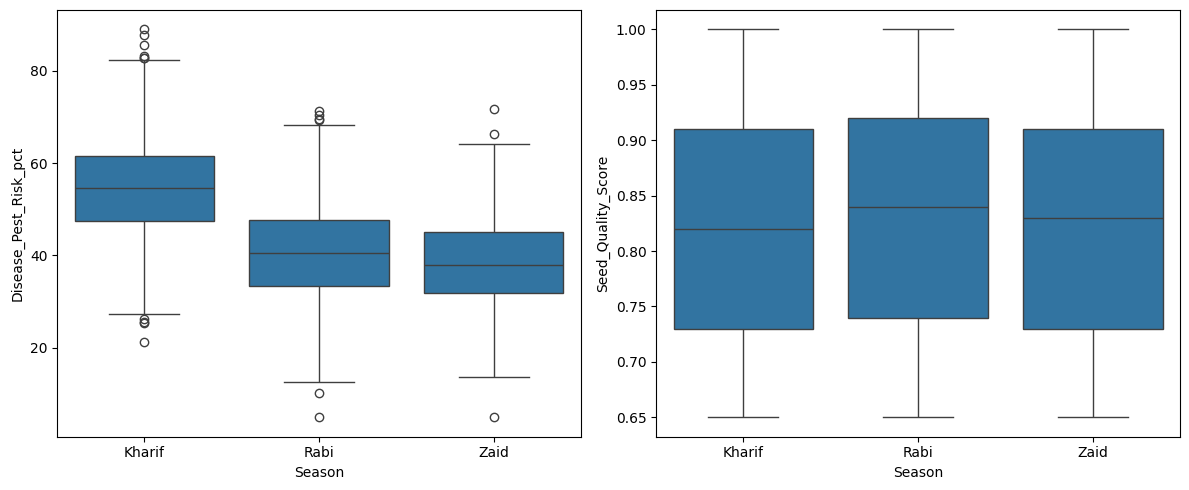

In [48]:
risk_summary = df.groupby('Season')[['Disease_Pest_Risk_pct','Seed_Quality_Score']].mean().round(2)
print(risk_summary)

fig, axes = plt.subplots(1,2, figsize=(12,5))
sns.boxplot(x='Season', y='Disease_Pest_Risk_pct', data=df, ax=axes[0])
sns.boxplot(x='Season', y='Seed_Quality_Score', data=df, ax=axes[1])
plt.tight_layout()
plt.show()

## Key Insights

- Kharif season, despite receiving the highest rainfall, shows the highest yield and profit , along with the largest number of profit outliers (211 out of 404), indicating financial risk and inconsistency.
- Zaid season shows more stable profit outcomes with the few outliers (43), and the lowest disease/pest risk (38.22%).
- Disease/Pest risk is highest in Kharif (54.47%), due to higher rainfall and humidity creating favorable conditions for pests and diseases.
- Seed Quality Score remains constant across all seasons (0.82–0.83), showing it is not season dependent.
- This suggests that Kharif season farming carries higher financial risk and unpredictability compared to Zaid, which is important for seasonal agricultural planning and risk management.

## Conclusion & Recommendations

**Conclusion:**
This analysis of seasonal agricultural performance reveals clear difference between Kharif, Rabi, and Zaid seasons. Kharif season, despite receiving the highest rainfall, shows greater variability in yield and profit, along with the highest disease/pest risk and the largest number of profit outliers, indicating higher risk and inconsistency. Zaid season shows more stable profit outcomes, the lowest disease/pest risk, and better water efficiency in several regions, suggesting more predictable and controlled farming conditions. Rabi season performs moderately . Seed quality remains consistent across all seasons, confirming it is not a season-dependent factor. Overall, seasonal environmental conditions — particularly rainfall, humidity, and temperature — play a significant role in determining yield, profit, and risk levels.

**Recommendations:**
1. Strengthen pest and disease management practices specifically during Kharif season to reduce crop losses and profit.
2. Promote more efficient irrigation methods during high water-usage seasons to improve water efficiency.
3. Encourage risk mitigation strategies (e.g., crop insurance) in high-risk regions/seasons to reduce the impact of profit outliers.
4. Since seed quality does not vary by season, focus improvement efforts on supplier standards rather than seasonal adjustment.
5. Use Zaid season's more stable practices as a reference model to improve consistency in Kharif and Rabi seasons.